### IMPORT

In [1]:
from pathlib import Path

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader
import rootutils

rootutils.setup_root(Path(".").resolve(), indicator=".project-root", pythonpath=True)

from src.models.bev_emb import BEVAdapterCNN
from src.models.bevqa import BEVQA_CNN
from src.data.bevqa_dataset import BEVQADataset
from src.models.head import OutputHead
from src.models.mca import MCALayer
from src.models.text_emb import TextAdapter
from src.training.train import train_epoch, val_epoch

device = "cuda" if torch.cuda.is_available() else "cpu"

### PATH

In [2]:
ROOT = Path("/home/robesafe-sandra/BEV")
DISK = Path("/media/robesafe-sandra/Datos")
MINI_DIR = DISK / "dataset_mini"
MINI_DICT_DIR = MINI_DIR / "dict_mini"
MINI_FEAT_DIR = MINI_DIR / "bev_features_mini"

GLOVE = ROOT/ "glove.6B/glove.6B.300d.txt"
#hydra 

### DATASET

In [3]:
train_dataset = BEVQADataset(
    bev_dir=MINI_FEAT_DIR / "train_mini",
    json_path=MINI_DICT_DIR / "NuScenes_train_questions_mini.json",
    glove=GLOVE
)

In [4]:
val_dataset = BEVQADataset(
    bev_dir=MINI_FEAT_DIR / "val_mini",
    json_path=MINI_DICT_DIR / "NuScenes_val_questions_mini.json",
    glove=GLOVE
)

In [5]:
feat, quest, ans = train_dataset[0]
print(feat.shape, quest.shape, ans)

torch.Size([128, 200, 200]) torch.Size([35, 300]) tensor(26)


torch.Size([128, 200, 200]) torch.Size([35, 300]) tensor(26)


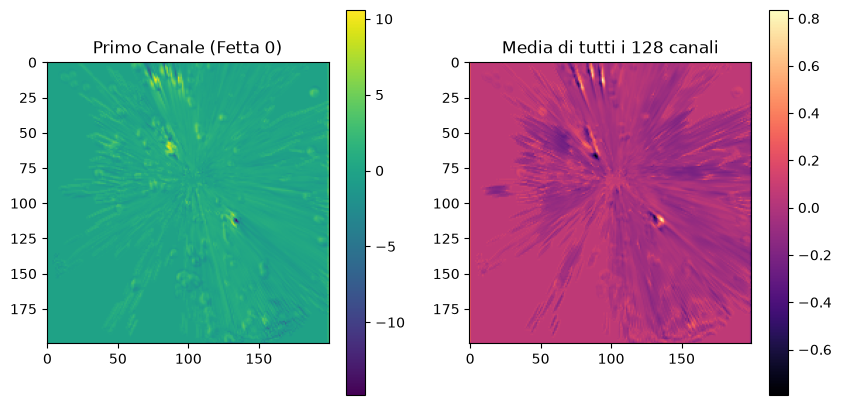

In [6]:
feat, quest, ans = train_dataset[0]
print(feat.shape, quest.shape, ans)

import matplotlib.pyplot as plt
import torch

# Convertiamo in numpy (staccando dal gradiente se necessario)
feat_np = feat.detach().cpu().numpy()

plt.figure(figsize=(10, 5))

# Opzione A: Visualizza il primo canale (indice 0)
plt.subplot(1, 2, 1)
plt.imshow(feat_np[0], cmap='viridis')
plt.title("Primo Canale (Fetta 0)")
plt.colorbar()

# Opzione B: Visualizza la media di tutti i 128 canali
plt.subplot(1, 2, 2)
plt.imshow(feat_np.mean(axis=0), cmap='magma')
plt.title("Media di tutti i 128 canali")
plt.colorbar()

plt.show()

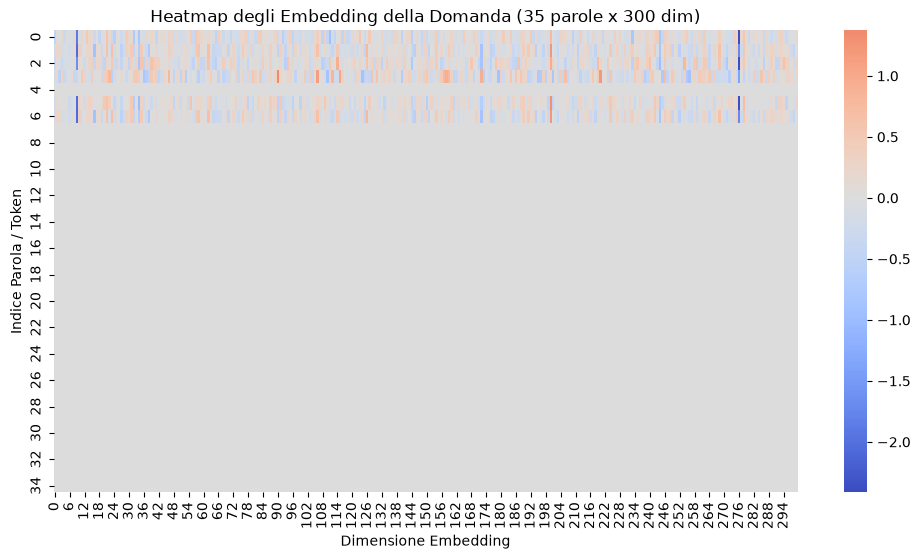

In [7]:
import seaborn as sns

quest_np = quest.detach().cpu().numpy()

plt.figure(figsize=(12, 6))
# Usiamo seaborn per una heatmap pulita
sns.heatmap(quest_np, cmap='coolwarm', center=0)
plt.title("Heatmap degli Embedding della Domanda (35 parole x 300 dim)")
plt.xlabel("Dimensione Embedding")
plt.ylabel("Indice Parola / Token")
plt.show()

In [8]:
# Estraiamo il valore numerico puro dal tensore
risposta_id = ans.item()

print(f"ID della Risposta: {risposta_id}")

# Se hai una lista/dizionario di parole del vocabolario (es. vocab), puoi fare:
# print(f"Parola corrispondente: {vocab[risposta_id]}")

ID della Risposta: 26


### DATALOADER

In [9]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [10]:
feat, quest, ans = next(iter(train_dataloader))
print(feat.shape, quest.shape, ans)

torch.Size([4, 128, 200, 200]) torch.Size([4, 35, 300]) tensor([23, 29, 18, 18])


### EMBEDDINGS

In [11]:
bev_ad = BEVAdapterCNN() # BEV MAP -> BEV EMB
text_ad = TextAdapter() # [B,35,512] to match BEV emb [B,400,512] 
feat_output = bev_ad(feat)
text_output = text_ad(quest)
print(f"Feat:{feat_output.shape}") # [B,100,512]
print(f"Text:{text_output.shape}") # [B,35,512]

Feat:torch.Size([4, 100, 512])
Text:torch.Size([4, 35, 512])


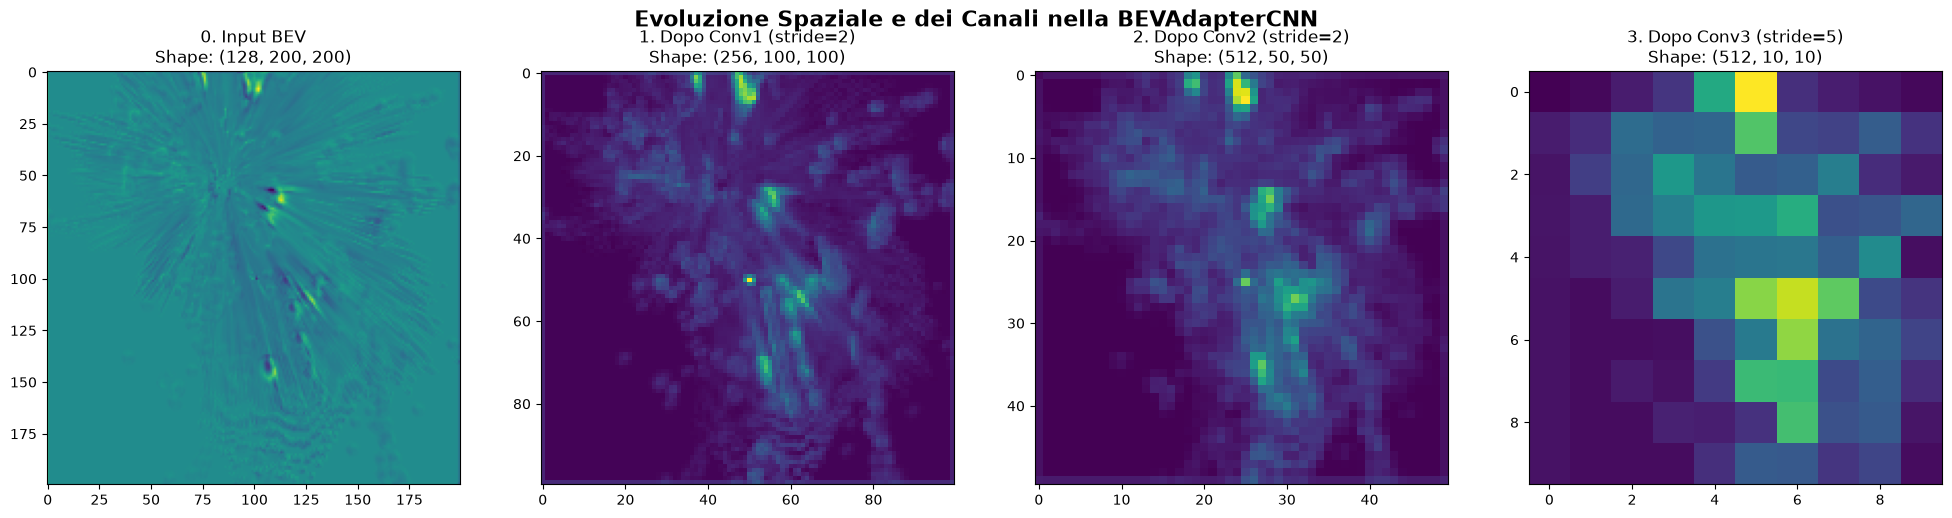

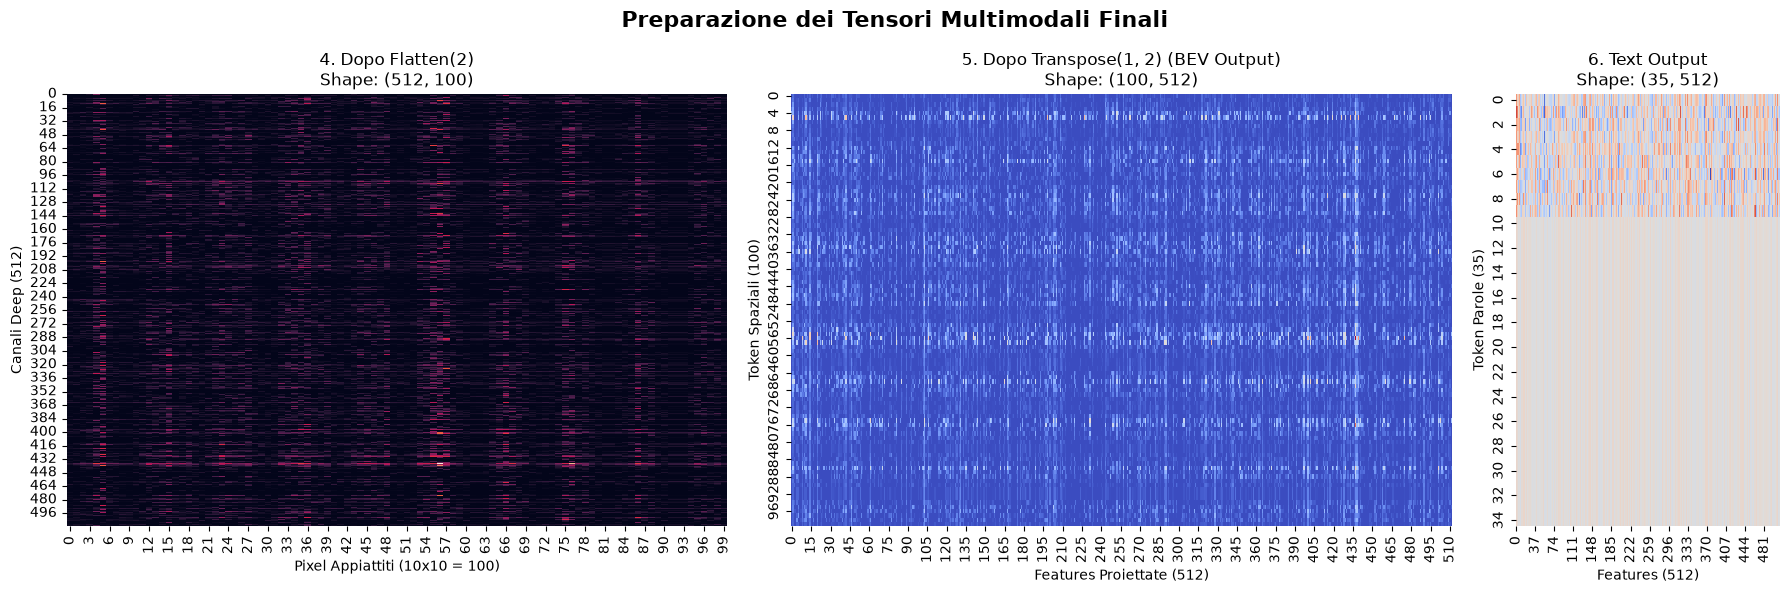

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Istanziamo i tuoi moduli originali
bev_ad = BEVAdapterCNN()
# Simuliamo un TextAdapter che mappa il testo a 512 (es. una proiezione lineare)
text_ad = nn.Linear(300, 512) 

# Estraiamo i singoli blocchi della CNN per analizzare i passaggi intermedi
conv1 = bev_ad.encoder[0:2] # Conv1 + ReLU
conv2 = bev_ad.encoder[2:4] # Conv2 + ReLU
conv3 = bev_ad.encoder[4:6] # Conv3 + ReLU

# ---------------------------------------------------------------------
# ESECUZIONE PASSO PASSO (Prendiamo solo il primo elemento del batch [0])
# ---------------------------------------------------------------------
with torch.no_grad():
    # Input iniziale
    x0 = feat[0:1] # Manteniamo la dimensione del batch fittizia per i layer [1, 128, 200, 200]
    
    # Passaggi CNN
    x1 = conv1(x0) # [1, 256, 100, 100]
    x2 = conv2(x1) # [1, 512, 50, 50]
    x3 = conv3(x2) # [1, 512, 10, 10]
    
    # Flatten e Transpose finale
    x_flat = x3.flatten(2)           # [1, 512, 100]
    x_final = x_flat.transpose(1, 2) # [1, 100, 512]
    
    # Processamento Testo
    text_output_all = text_ad(quest)
    text_final = text_output_all[0:1] # [1, 35, 512]

# Rimuoviamo la dimensione del batch per plottare in numpy
img_0 = x0.squeeze(0).detach().cpu().numpy()
img_1 = x1.squeeze(0).detach().cpu().numpy()
img_2 = x2.squeeze(0).detach().cpu().numpy()
img_3 = x3.squeeze(0).detach().cpu().numpy()
mat_flat = x_flat.squeeze(0).detach().cpu().numpy()
mat_final = x_final.squeeze(0).detach().cpu().numpy()
mat_text = text_final.squeeze(0).detach().cpu().numpy()


# =====================================================================
# VISUALIZZAZIONE 1: L'evoluzione spaziale dentro la CNN
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Facciamo la media sui canali per vedere l'attivazione spaziale macro
axes[0].imshow(img_0.mean(axis=0), cmap='viridis')
axes[0].set_title(f"0. Input BEV\nShape: {img_0.shape}")

axes[1].imshow(img_1.mean(axis=0), cmap='viridis')
axes[1].set_title(f"1. Dopo Conv1 (stride=2)\nShape: {img_1.shape}")

axes[2].imshow(img_2.mean(axis=0), cmap='viridis')
axes[2].set_title(f"2. Dopo Conv2 (stride=2)\nShape: {img_2.shape}")

axes[3].imshow(img_3.mean(axis=0), cmap='viridis')
axes[3].set_title(f"3. Dopo Conv3 (stride=5)\nShape: {img_3.shape}")

plt.suptitle("Evoluzione Spaziale e dei Canali nella BEVAdapterCNN", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# =====================================================================
# VISUALIZZAZIONE 2: Flatten, Transpose e Allineamento con il Testo
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1, 0.4]})

# Grafico A: Dopo il Flatten
sns.heatmap(mat_flat, cmap='rocket', ax=axes[0], cbar=False)
axes[0].set_title(f"4. Dopo Flatten(2)\nShape: {mat_flat.shape}")
axes[0].set_ylabel("Canali Deep (512)")
axes[0].set_xlabel("Pixel Appiattiti (10x10 = 100)")

# Grafico B: Dopo il Transpose (Pronto per l'attenzione)
sns.heatmap(mat_final, cmap='coolwarm', ax=axes[1], cbar=False)
axes[1].set_title(f"5. Dopo Transpose(1, 2) (BEV Output)\nShape: {mat_final.shape}")
axes[1].set_ylabel("Token Spaziali (100)")
axes[1].set_xlabel("Features Proiettate (512)")

# Grafico C: L'output del Testo per il confronto grafico
sns.heatmap(mat_text, cmap='coolwarm', ax=axes[2], cbar=False)
axes[2].set_title(f"6. Text Output\nShape: {mat_text.shape}")
axes[2].set_ylabel("Token Parole (35)")
axes[2].set_xlabel("Features (512)")

plt.suptitle("Preparazione dei Tensori Multimodali Finali", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### MODEL

In [13]:
model = BEVQA_CNN()
out = model(feat, quest)
print(out.shape) # [4, 30]

torch.Size([4, 30])


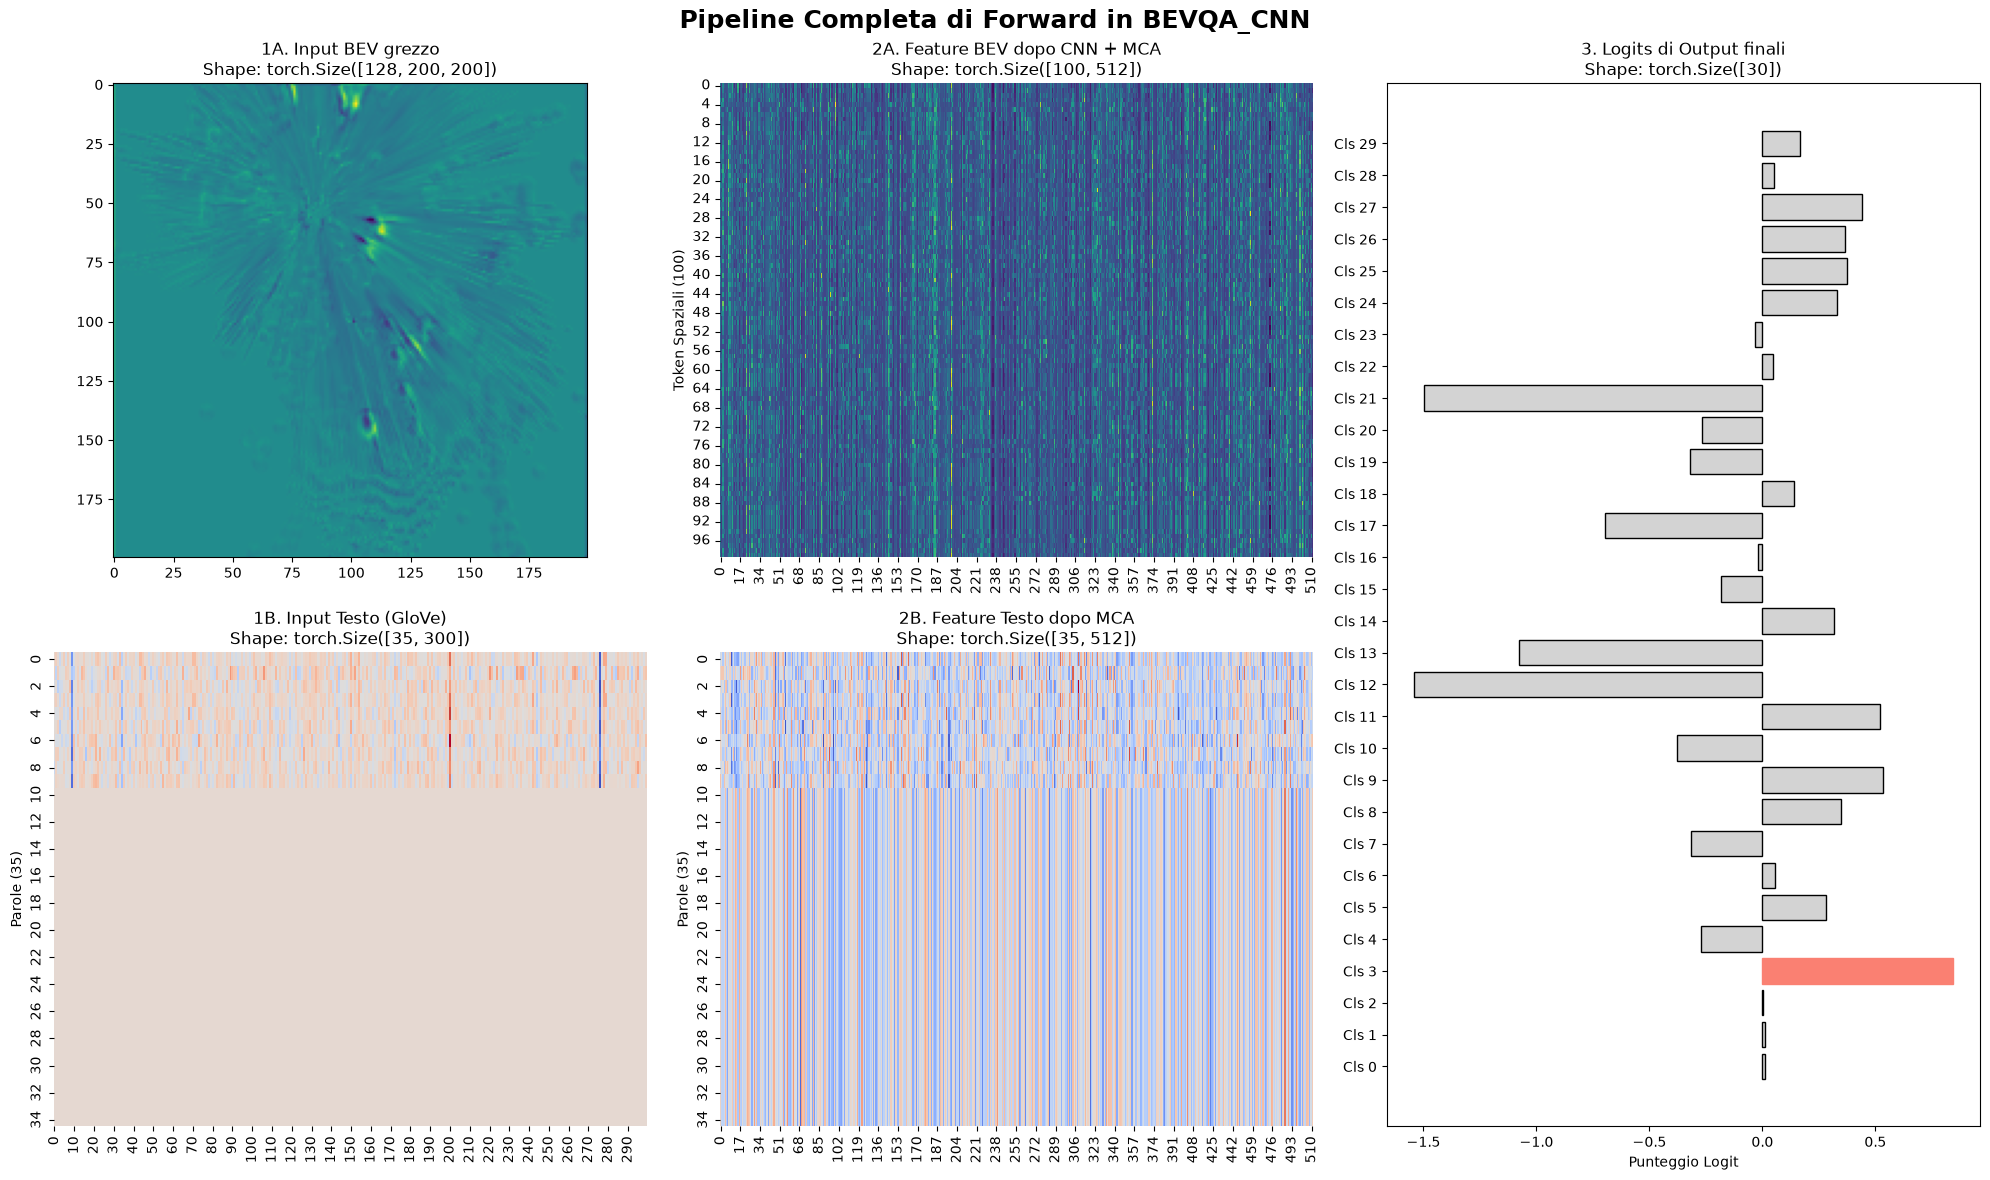

RISPOSTA REALE (Target): 'stopped' (ID: 23)
RISPOSTA PREDETTA      : '2' (ID: 3)


In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Supponiamo che tu abbia già istanziato il modello completo
model = BEVQA_CNN()

# Per poter visualizzare i passaggi intermedi, estraiamo i singoli blocchi dal modello
bev_adapter = model.bev_adapter
text_adapter = model.text_adapter
mca = model.mca
head = model.head

# Riprendiamo il dizionario inverso che abbiamo creato prima per decodificare la risposta
idx2answer = {idx: ans for ans, idx in train_dataset.answer2idx.items()}

# ---------------------------------------------------------------------
# FORWARD PASS TRACCIATO (Prendiamo il primo elemento del batch [0])
# ---------------------------------------------------------------------
with torch.no_grad():
    # Step 1: Input originali
    feat_init = feat[0:1] # [1, 128, 200, 200]
    quest_init = quest[0:1] # [1, 35, 300]
    
    # Step 2: Adapters
    bev_mapped = bev_adapter(feat_init)   # [1, 100, 512]
    text_mapped = text_adapter(quest_init) # [1, 35, 512]
    
    # Step 3: Co-Attention (MCA)
    bev_mca, text_mca = mca(bev_mapped, text_mapped) # [1, 100, 512], [1, 35, 512]
    
    # Step 4: Output Head e Predizione
    logits = head(text_mca) # [1, 30]

# Estraiamo i dati per i grafici (rimuovendo la dimensione del batch)
vis_bev_init = feat_init.squeeze(0).detach().cpu().numpy().mean(axis=0) # 200x200
vis_text_init = quest_init.squeeze(0).detach().cpu().numpy() # 35x300
vis_bev_mca = bev_mca.squeeze(0).detach().cpu().numpy() # 100x512
vis_text_mca = text_mca.squeeze(0).detach().cpu().numpy() # 35x512
vis_logits = logits.squeeze(0).detach().cpu().numpy() # 30

# =====================================================================
# MAXI-VISUALIZZAZIONE: IL FLUSSO DI BEVQA_CNN
# =====================================================================
fig = plt.figure(figsize=(20, 12))

# --- RIGA 1: GLI INPUT GREZZI ---
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(vis_bev_init, cmap='viridis')
ax1.set_title(f"1A. Input BEV grezzo\nShape: {feat.shape[1:]}")

ax2 = plt.subplot(2, 3, 4)
sns.heatmap(vis_text_init, cmap='coolwarm', ax=ax2, cbar=False)
ax2.set_title(f"1B. Input Testo (GloVe)\nShape: {quest.shape[1:]}")
ax2.set_ylabel("Parole (35)")

# --- RIGA 2: DOPO GLI ADAPTERS & MCA (Allineamento) ---
ax3 = plt.subplot(2, 3, 2)
sns.heatmap(vis_bev_mca, cmap='viridis', ax=ax3, cbar=False)
ax3.set_title(f"2A. Feature BEV dopo CNN + MCA\nShape: {bev_mca.shape[1:]}")
ax3.set_ylabel("Token Spaziali (100)")

ax4 = plt.subplot(2, 3, 5)
sns.heatmap(vis_text_mca, cmap='coolwarm', ax=ax4, cbar=False)
ax4.set_title(f"2B. Feature Testo dopo MCA\nShape: {text_mca.shape[1:]}")
ax4.set_ylabel("Parole (35)")

# --- RIGA 3: IL VERDETTO FINALE ---
ax5 = plt.subplot(1, 3, 3)
classi = [f"Cls {i}" for i in range(30)]
bars = ax5.barh(classi, vis_logits, color='lightgray', edgecolor='black')

# Evidenziamo la predizione del modello
pred_idx = vis_logits.argmax()
target_idx = ans[0].item()
bars[pred_idx].set_color('salmon')

ax5.set_title(f"3. Logits di Output finali\nShape: {logits.shape[1:]}")
ax5.set_xlabel("Punteggio Logit")

plt.suptitle("Pipeline Completa di Forward in BEVQA_CNN", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# DECODIFICA FINALE IN STRINGHE
# =====================================================================
print("=" * 60)
print(f"RISPOSTA REALE (Target): '{idx2answer.get(target_idx, 'Sconosciuto')}' (ID: {target_idx})")
print(f"RISPOSTA PREDETTA      : '{idx2answer.get(pred_idx, 'Sconosciuto')}' (ID: {pred_idx})")
print("=" * 60)

### TRAIN

In [14]:
model = BEVQA_CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    tr_loss, tr_acc = train_epoch(model, train_dataloader, optimizer, criterion, device)
    val_loss, val_acc = val_epoch(model, val_dataloader, criterion, device)
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
              f"Train Loss: {tr_loss:.4f} - Acc: {tr_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f}")

KeyboardInterrupt: 